# Negative Log-Likelihood (Predictive Log-Loss) Analysis

This notebook analyzes the predictive log-loss for uncertainty quantification quality.

**Key Finding Preview:** Random forest methods exhibit extreme instability with massive outliers, while smoothed random forests show complete stability.

Log-loss jointly evaluates:
- Point prediction accuracy
- Uncertainty calibration
- Interval sharpness

Lower values indicate better performance.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

In [20]:
logloss_combined_df = pd.read_csv('./metrics/logloss_combined_all_data.csv')

In [25]:
models = ['RF(10)', 'RF(20)', 'RF(50)', 'RF(100)',
       'GP', 'EST-PD(Norm)', 'EST-PD(Hypsec)', 'STE(Norm)', 'STE(Hypsec)',
       'STE-PD(Norm)', 'STE-PD(Hypsec)', 'EST(Norm)', 'EST(Hypsec)']

In [26]:
print("="*80)
print("OUTLIER ANALYSIS: Percentage of experiments with log-loss > 100")
print("="*80)

outlier_stats = []
threshold = 100  # Log-loss > 100 indicates severe instability

for model in models:
    outliers = logloss_combined_df[model] > threshold
    n_outliers = outliers.sum()
    pct_outliers = 100 * n_outliers / len(logloss_combined_df)
    max_val = logloss_combined_df[model].max()
    
    outlier_stats.append({
        'Model': model,
        'N_Outliers': n_outliers,
        'Pct_Outliers': pct_outliers,
        'Max_Value': max_val
    })

outlier_df = pd.DataFrame(outlier_stats).sort_values('Pct_Outliers', ascending=False)
print(outlier_df.to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print(f"1. RF(10): {outlier_df.iloc[0]['Pct_Outliers']:.1f}% of experiments are unstable")
print(f"2. Even RF(100): {outlier_df[outlier_df['Model']=='RF(100)']['Pct_Outliers'].values[0]:.1f}% unstable")
print(f"3. Largest outlier: {outlier_df.iloc[0]['Max_Value']:.2e} (RF method)")

OUTLIER ANALYSIS: Percentage of experiments with log-loss > 100
         Model  N_Outliers  Pct_Outliers    Max_Value
        RF(10)        1679     31.679245 9.854210e+31
        RF(20)         806     15.207547 4.107339e+31
            GP         321      6.056604 5.898255e+03
        RF(50)         226      4.264151 5.121821e+30
       RF(100)          60      1.132075 5.607890e+28
  EST-PD(Norm)           0      0.000000 5.079244e+00
EST-PD(Hypsec)           0      0.000000 5.068873e+00
     STE(Norm)           0      0.000000 7.289846e+00
   STE(Hypsec)           0      0.000000 5.898116e+00
  STE-PD(Norm)           0      0.000000 4.275230e+00
STE-PD(Hypsec)           0      0.000000 4.265707e+00
     EST(Norm)           0      0.000000 4.223342e+00
   EST(Hypsec)           0      0.000000 4.190753e+00

KEY INSIGHTS:
1. RF(10): 31.7% of experiments are unstable
2. Even RF(100): 1.1% unstable
3. Largest outlier: 9.85e+31 (RF method)


In [27]:
# Calculate robust statistics
robust_stats = []

for model in models:
    data = logloss_combined_df[model]
    
    robust_stats.append({
        'Model': model,
        'Median': data.median(),
        'Q1': data.quantile(0.25),
        'Q3': data.quantile(0.75),
        'IQR': data.quantile(0.75) - data.quantile(0.25),
        'Min': data.min(),
        'Max': data.max(),
        'Mean': data.mean(),
        'Std': data.std()
    })

robust_df = pd.DataFrame(robust_stats).sort_values('Median')

print("\n" + "="*80)
print("ROBUST STATISTICS (sorted by median log-loss)")
print("="*80)
print("\nLower is better (better calibration + accuracy)\n")
print(robust_df[['Model', 'Median', 'Q1', 'Q3', 'IQR', 'Min']].to_string(index=False))


ROBUST STATISTICS (sorted by median log-loss)

Lower is better (better calibration + accuracy)

         Model   Median       Q1           Q3          IQR       Min
   STE(Hypsec) 1.598342 1.157867 2.134913e+00 9.770465e-01 -2.777368
     STE(Norm) 1.600471 1.161214 2.142577e+00 9.813630e-01 -3.239294
  EST-PD(Norm) 1.630465 1.212261 2.128065e+00 9.158041e-01 -3.389074
       RF(100) 1.633785 1.133050 2.715812e+00 1.582762e+00 -3.850012
EST-PD(Hypsec) 1.637485 1.218706 2.133156e+00 9.144502e-01 -3.354998
     EST(Norm) 1.708192 1.246635 2.964474e+00 1.717839e+00 -2.742027
  STE-PD(Norm) 1.734092 1.252662 2.175306e+00 9.226438e-01 -2.771657
   EST(Hypsec) 1.742678 1.262199 3.010399e+00 1.748201e+00 -2.743769
        RF(50) 1.751758 1.167997 3.131611e+00 1.963613e+00 -3.857763
STE-PD(Hypsec) 1.775777 1.267675 2.183241e+00 9.155666e-01 -2.777368
            GP 1.927070 1.135215 3.712284e+00 2.577069e+00 -2.827577
        RF(20) 2.263099 1.314860 5.434866e+00 4.120006e+00 -3.818001
      

In [28]:
print("\n" + "="*80)
print("MEAN vs MEDIAN Comparison (shows outlier impact)")
print("="*80)
print(robust_df[['Model', 'Mean', 'Median']].to_string(index=False))


MEAN vs MEDIAN Comparison (shows outlier impact)
         Model         Mean   Median
   STE(Hypsec) 1.395908e+00 1.598342
     STE(Norm) 1.396981e+00 1.600471
  EST-PD(Norm) 1.347790e+00 1.630465
       RF(100) 5.834764e+25 1.633785
EST-PD(Hypsec) 1.357419e+00 1.637485
     EST(Norm) 1.507237e+00 1.708192
  STE-PD(Norm) 1.457159e+00 1.734092
   EST(Hypsec) 1.553072e+00 1.742678
        RF(50) 3.442830e+27 1.751758
STE-PD(Hypsec) 1.481964e+00 1.775777
            GP 5.363719e+01 1.927070
        RF(20) 2.835544e+28 2.263099
        RF(10) 1.480327e+29 4.885547


In [29]:
robust_stats

[{'Model': 'RF(10)',
  'Median': 4.885546718175197,
  'Q1': np.float64(1.7361405489687827),
  'Q3': np.float64(1.12274652775792e+24),
  'IQR': np.float64(1.12274652775792e+24),
  'Min': -3.6821579094973456,
  'Max': 9.854210003316437e+31,
  'Mean': np.float64(1.4803273896657877e+29),
  'Std': 1.8297256392646568e+30},
 {'Model': 'RF(20)',
  'Median': 2.263098795412759,
  'Q1': np.float64(1.3148604357422298),
  'Q3': np.float64(5.434866229737716),
  'IQR': np.float64(4.120005793995487),
  'Min': -3.818001395350503,
  'Max': 4.107339306005163e+31,
  'Mean': np.float64(2.8355439178561996e+28),
  'Std': 6.0535585147205756e+29},
 {'Model': 'RF(50)',
  'Median': 1.7517583436848223,
  'Q1': np.float64(1.167997479925996),
  'Q3': np.float64(3.131610759250265),
  'IQR': np.float64(1.963613279324269),
  'Min': -3.857762911438206,
  'Max': 5.121820606982743e+30,
  'Mean': np.float64(3.4428300605651615e+27),
  'Std': 1.1479787112753548e+29},
 {'Model': 'RF(100)',
  'Median': 1.6337851517924453,
  '

In [30]:
# Median log-loss by dataset
dataset_median = logloss_combined_df.groupby('Data')[models].median().reset_index()

# Rename columns

print("="*80)
print("MEDIAN LOG-LOSS BY DATASET")
print("="*80)
dataset_median.round(2)

MEDIAN LOG-LOSS BY DATASET


,Data,RF(10),RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec),STE(Norm),STE(Hypsec),STE-PD(Norm),STE-PD(Hypsec),EST(Norm),EST(Hypsec)
0,CCPP,3.893298e+23,4.33,3.21,3.12,3.54,3.04,3.06,3.06,3.07,3.05,3.06,3.01,3.05
1,Fertility,1.830000e+00,0.75,0.44,0.40,0.67,-0.25,-0.25,-0.25,-0.25,-0.22,-0.22,-0.23,-0.22
2,Forest,5.525736e+28,3.65,2.27,2.11,2.79,1.80,1.80,1.78,1.78,1.78,1.78,1.79,1.78
3,Qsar Aquatic Toxicity,4.360000e+00,2.15,1.80,1.71,1.97,1.71,1.71,1.67,1.66,1.85,1.93,1.76,1.83
4,Qsar Fish Toxicity,1.919432e+25,2.53,1.70,1.58,2.13,1.47,1.47,1.42,1.41,1.68,1.77,1.57,1.66
5,Real Estate,9.334000e+01,5.11,4.03,3.87,4.79,3.55,3.56,3.72,3.74,3.71,3.72,3.72,3.72
6,Stock,-3.200000e+00,-3.47,-3.58,-3.61,-2.68,-3.06,-3.04,-2.67,-2.68,-2.67,-2.68,-2.59,-2.63
7,Winequality (Red),2.860000e+00,1.32,1.10,1.07,1.02,1.16,1.16,1.09,1.09,1.21,1.22,1.20,1.21
8,Winequality (White),3.410000e+00,1.54,1.24,1.20,1.21,1.26,1.27,1.25,1.24,1.28,1.29,1.28,1.29
9,Yacht Hydrodynamics,1.680000e+00,1.56,1.58,1.60,2.74,2.17,2.21,2.15,2.16,2.26,2.31,3.05,3.46


In [31]:
# Create comprehensive summary
summary_table = pd.DataFrame({
    'Model': models,
    'Median': [logloss_combined_df[m].median() for m in models],
    'IQR': [logloss_combined_df[m].quantile(0.75) - logloss_combined_df[m].quantile(0.25) for m in models],
    'Min': [logloss_combined_df[m].min() for m in models],
    'Max': [logloss_combined_df[m].max() for m in models],
    'N_Outliers': [(logloss_combined_df[m] > 100).sum() for m in models],
    'Pct_Outliers': [100 * (logloss_combined_df[m] > 100).sum() / len(logloss_combined_df) for m in models],
    'Stable': ['Yes' if (logloss_combined_df[m] > 100).sum() == 0 else 'No' for m in models]
})

summary_table = summary_table.sort_values('Median')

print("="*80)
print("COMPREHENSIVE SUMMARY TABLE")
print("="*80)
summary_table.round(4)

# Save to CSV
#summary_table.to_csv('logloss_summary_statistics.csv', index=False)


COMPREHENSIVE SUMMARY TABLE


,Model,Median,IQR,Min,Max,N_Outliers,Pct_Outliers,Stable
8,STE(Hypsec),1.5983,9.770000e-01,-2.7774,5.898100e+00,0,0.0000,Yes
7,STE(Norm),1.6005,9.814000e-01,-3.2393,7.289800e+00,0,0.0000,Yes
5,EST-PD(Norm),1.6305,9.158000e-01,-3.3891,5.079200e+00,0,0.0000,Yes
3,RF(100),1.6338,1.582800e+00,-3.8500,5.607890e+28,60,1.1321,No
6,EST-PD(Hypsec),1.6375,9.145000e-01,-3.3550,5.068900e+00,0,0.0000,Yes
11,EST(Norm),1.7082,1.717800e+00,-2.7420,4.223300e+00,0,0.0000,Yes
9,STE-PD(Norm),1.7341,9.226000e-01,-2.7717,4.275200e+00,0,0.0000,Yes
12,EST(Hypsec),1.7427,1.748200e+00,-2.7438,4.190800e+00,0,0.0000,Yes
2,RF(50),1.7518,1.963600e+00,-3.8578,5.121821e+30,226,4.2642,No
10,STE-PD(Hypsec),1.7758,9.156000e-01,-2.7774,4.265700e+00,0,0.0000,Yes


In [32]:
logloss_pi = pd.DataFrame()
logloss_pi['Data'] = logloss_combined_df['Data']
logloss_pi['p'] = logloss_combined_df['p']
logloss_pi['n'] = logloss_combined_df['n_obs']
logloss_pi['r'] = logloss_combined_df['r']

for model in models[1:]:
    logloss_pi[model] = (logloss_combined_df['RF(10)']-logloss_combined_df[model])/logloss_combined_df['RF(10)']*100

In [33]:
logloss_pi.to_csv('logloss_pi.csv', index=False)

In [34]:
logloss_pi = pd.read_csv('logloss_pi.csv')

In [35]:
def standard_error_median(df, groupby_cols, value_cols):
    results = []
    
    grouped = df.groupby(groupby_cols)
    for group, group_df in grouped:
        row = list(group) if isinstance(group, tuple) else [group]
        P = group_df['p'].unique()[0]
        row.extend([P])
        n = len(group_df)
        if n == 0:
            row.append(None)
            continue
        for col in value_cols:
            data = group_df[col].dropna().values  # Drop NaN values
            
            
            sample_median = np.median(data)
            
            # Estimate f(m) using KDE (Kernel Density Estimation)
            kde = stats.gaussian_kde(data)
            f_m = kde(sample_median)[0]  # Ensure f_m is a scalar
            
            # Theoretical SE using asymptotic formula
            se_median_theoretical = 1 / (2 * f_m * np.sqrt(n))
            
            
            row.append(se_median_theoretical)
        
        results.append(row)
    
    column_names = list(groupby_cols) + ['p'] + [f"{col}" for col in value_cols]
    return pd.DataFrame(results, columns=column_names).sort_values(by=['p'])

In [36]:
logloss_PI_se = standard_error_median(logloss_pi, ['Data'], models[1:])

In [37]:
logloss_PI_meadian = logloss_pi.groupby('Data').median().reset_index().drop(columns=['n', 'r'])

In [39]:
logloss_PI_median_CI = pd.DataFrame()
logloss_PI_median_CI['Data'] = logloss_PI_meadian['Data']
logloss_PI_median_CI['p'] = logloss_PI_meadian['p'].astype(int)

#CV_logloss_median_CI['RF(10)'] = round(cv_logloss_meadian['RF(10)'],4).astype(str) + ' (' + cv_logloss_pi_se['RF(10)'].apply(lambda x: f'{x:.2e}') + ')'
#CV_logloss_median_CI['RF(20)'] = round(cv_logloss_meadian['RF(20)'],4).astype(str) + ' (' + cv_logloss_pi_se['RF(20)'].apply(lambda x: f'{x:.2e}') + ')'
#CV_logloss_median_CI['RF(50)'] = round(cv_logloss_meadian['RF(50)'],4).astype(str) + ' (' + cv_logloss_pi_se['RF(50)'].apply(lambda x: f'{x:.2e}') + ')'
logloss_PI_median_CI['RF(100)'] = round(logloss_PI_meadian['RF(100)'],4).astype(str) + ' (' + logloss_PI_se['RF(100)'].apply(lambda x: f'{x:.2e}') + ')'
logloss_PI_median_CI['GP'] = round(logloss_PI_meadian['GP'], 4).astype(str) + ' (' + logloss_PI_se['GP'].apply(lambda x: f'{x:.2e}') + ')'
logloss_PI_median_CI['EST-PD(Norm)'] = round(logloss_PI_meadian['EST-PD(Norm)'],4).astype(str) + ' (' + logloss_PI_se['EST-PD(Norm)'].apply(lambda x: f'{x:.2e}') + ')'
logloss_PI_median_CI['EST-PD(Hypsec)'] = round(logloss_PI_meadian['EST-PD(Hypsec)'],4).astype(str) + ' (' + logloss_PI_se['EST-PD(Hypsec)'].apply(lambda x: f'{x:.2e}') + ')'
logloss_PI_median_CI['STE(Norm)'] = round(logloss_PI_meadian['STE(Norm)'],4).astype(str) + ' (' + logloss_PI_se['STE(Norm)'].apply(lambda x: f'{x:.2e}') + ')'
logloss_PI_median_CI['STE(Hypsec)'] = round(logloss_PI_meadian['STE(Hypsec)'],4).astype(str) + ' (' + logloss_PI_se['STE(Hypsec)'].apply(lambda x: f'{x:.2e}') + ')'

In [40]:
logloss_PI_meadian.columns

Index(['Data', 'p', 'RF(20)', 'RF(50)', 'RF(100)', 'GP', 'EST-PD(Norm)',
       'EST-PD(Hypsec)', 'STE(Norm)', 'STE(Hypsec)', 'STE-PD(Norm)',
       'STE-PD(Hypsec)', 'EST(Norm)', 'EST(Hypsec)'],
      dtype='object')

In [41]:
other_smoothing_mode_median_PI = pd.DataFrame()


In [42]:
logloss_PI_median_CI.to_csv('logloss_PI_median_CI.csv', index=False)

In [43]:
logloss_PI_median_CI = pd.read_csv('logloss_PI_median_CI.csv')

In [45]:
logloss_se = standard_error_median(logloss_combined_df, ['Data'], models[1:])
logloss_meadian = logloss_combined_df.groupby('Data').median().reset_index().drop(columns=['n_obs', 'r'])
logloss_median_CI = pd.DataFrame()
logloss_median_CI['Data'] = logloss_meadian['Data']
logloss_median_CI['p'] = logloss_meadian['p'].astype(int)


logloss_median_CI['RF(100)'] = round(logloss_meadian['RF(100)'],4).astype(str) + ' (' + logloss_se['RF(100)'].apply(lambda x: f'{x:.2e}') + ')'
logloss_median_CI['GP'] = round(logloss_meadian['GP'], 4).astype(str) + ' (' + logloss_se['GP'].apply(lambda x: f'{x:.2e}') + ')'
logloss_median_CI['EST-PD(Norm)'] = round(logloss_meadian['EST-PD(Norm)'],4).astype(str) + ' (' + logloss_se['EST-PD(Norm)'].apply(lambda x: f'{x:.2e}') + ')'
logloss_median_CI['EST-PD(Hypsec)'] = round(logloss_meadian['EST-PD(Hypsec)'],4).astype(str) + ' (' + logloss_se['EST-PD(Hypsec)'].apply(lambda x: f'{x:.2e}') + ')'
logloss_median_CI['STE(Norm)'] = round(logloss_meadian['STE(Norm)'],4).astype(str) + ' (' + logloss_se['STE(Norm)'].apply(lambda x: f'{x:.2e}') + ')'
logloss_median_CI['STE(Hypsec)'] = round(logloss_meadian['STE(Hypsec)'],4).astype(str) + ' (' + logloss_se['STE(Hypsec)'].apply(lambda x: f'{x:.2e}') + ')'
logloss_median_CI.to_csv('logloss_median_CI.csv', index=False)

In [46]:
from autorank import autorank, plot_stats, create_report, latex_table

In [70]:
stats_df = logloss_pi.drop(columns=['Data','n','p','r', 'EST(Norm)', 'EST(Hypsec)', 'STE-PD(Norm)', 'STE-PD(Hypsec)'])

In [71]:
result = autorank(stats_df, alpha=0.05, verbose=True, order='descending')

Rejecting null hypothesis that data is normal for column RF(20) (p=0.000000<0.006250)
Rejecting null hypothesis that data is normal for column RF(50) (p=0.000000<0.006250)
Rejecting null hypothesis that data is normal for column RF(100) (p=0.000000<0.006250)
Rejecting null hypothesis that data is normal for column GP (p=0.000000<0.006250)
Rejecting null hypothesis that data is normal for column EST-PD(Norm) (p=0.000000<0.006250)
Rejecting null hypothesis that data is normal for column EST-PD(Hypsec) (p=0.000000<0.006250)
Rejecting null hypothesis that data is normal for column STE(Norm) (p=0.000000<0.006250)
Rejecting null hypothesis that data is normal for column STE(Hypsec) (p=0.000000<0.006250)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.000000<0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemenyi post-hoc test. 

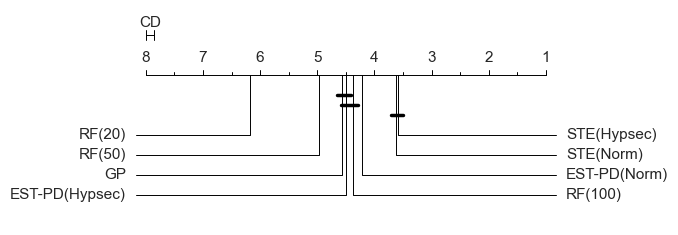

In [72]:
plot_stats(result)
plt.savefig('./logloss_cd.pdf', 
           dpi=300, bbox_inches='tight')

In [69]:
latex = latex_table(result)

\begin{table}[h]
\centering
\begin{tabular}{lrrllll}
\toprule
 & MR & MED & MAD & CI & $\gamma$ & Magnitude \\
\midrule
RF(20) & 9.095 & 31.270 & 41.415 & [26.429, 37.881] & 0.000 & negligible \\
RF(50) & 7.207 & 57.063 & 42.937 & [48.914, 64.991] & -0.412 & small \\
STE-PD(Hypsec) & 7.169 & 65.809 & 34.191 & [58.096, 74.295] & -0.613 & medium \\
EST(Hypsec) & 6.827 & 66.265 & 33.735 & [58.313, 74.388] & -0.625 & medium \\
GP & 6.764 & 53.030 & 46.970 & [42.808, 64.496] & -0.331 & small \\
STE-PD(Norm) & 6.394 & 66.366 & 33.634 & [58.592, 74.749] & -0.627 & medium \\
RF(100) & 6.383 & 61.631 & 38.369 & [54.242, 70.191] & -0.513 & medium \\
EST-PD(Hypsec) & 6.173 & 67.522 & 32.478 & [60.141, 75.308] & -0.657 & medium \\
EST(Norm) & 5.980 & 66.844 & 33.156 & [58.918, 74.846] & -0.640 & medium \\
EST-PD(Norm) & 5.810 & 67.813 & 32.187 & [60.393, 75.577] & -0.665 & medium \\
STE(Norm) & 5.105 & 67.998 & 32.002 & [60.570, 75.494] & -0.669 & medium \\
STE(Hypsec) & 5.092 & 68.531 & 31.469 & 

In [65]:
report = create_report(result)

The statistical analysis was conducted for 8 populations with 5300 paired samples.
The family-wise significance level of the tests is alpha=0.050.
We rejected the null hypothesis that the population is normal for the populations RF(20) (p=0.000), RF(50) (p=0.000), STE-PD(Hypsec) (p=0.000), GP (p=0.000), EST(Hypsec) (p=0.000), RF(100) (p=0.000), STE-PD(Norm) (p=0.000), and EST(Norm) (p=0.000). Therefore, we assume that not all populations are normal.
Because we have more than two populations and the populations and some of them are not normal, we use the non-parametric Friedman test as omnibus test to determine if there are any significant differences between the median values of the populations. We use the post-hoc Nemenyi test to infer which differences are significant. We report the median (MD), the median absolute deviation (MAD) and the mean rank (MR) among all populations over the samples. Differences between populations are significant, if the difference of the mean rank is great

In [54]:
logloss_mean = logloss_combined_df.groupby(['Data','p']).mean().drop(columns=['r','n_obs']).reset_index()
logloss_std = logloss_combined_df.groupby(['Data','p']).std().drop(columns=['r','n_obs']).reset_index()
logloss_combined_df['cases'] = 1
cased_by_n_obs = logloss_combined_df.groupby(['Data']).sum().reset_index()
logloss_std['cases'] = cased_by_n_obs['cases']

In [55]:
logloss_mean

,Data,p,RF(10),RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec),STE(Norm),STE(Hypsec),STE-PD(Norm),STE-PD(Hypsec),EST(Norm),EST(Hypsec)
0,CCPP,4,3.696523e+24,3.231544e+23,2.529596e+21,8.912498e+19,3.608069,3.068674,3.085329,3.091664,3.092911,3.075811,3.083995,3.044336,3.071903
1,Fertility,9,1.534125e+30,3.174680e+29,5.178916e+28,7.816539e-01,1029.139499,-0.243288,-0.242215,-0.180421,-0.183391,-0.203211,-0.202616,-0.210454,-0.201480
2,Forest,12,5.463911e+29,1.313756e+29,1.309931e+28,5.146998e+26,73.420457,1.820016,1.814295,1.803331,1.801953,1.804767,1.795237,1.808107,1.799701
3,Qsar Aquatic Toxicity,8,2.208252e+28,8.295929e+27,5.402589e+24,5.209305e+22,2.674368,1.724811,1.730283,1.704730,1.698957,1.852538,1.927170,1.769788,1.834585
4,Qsar Fish Toxicity,6,2.114910e+29,4.404321e+27,4.058645e+25,5.438357e+23,28.512393,1.488537,1.495333,1.445458,1.446151,1.678057,1.770624,1.574636,1.665293
5,Real Estate,6,3.979246e+27,5.593300e+26,3.970924e+24,1.300685e+23,25.438543,3.572660,3.578539,3.740844,3.753297,3.722488,3.736277,3.737115,3.741691
6,Stock,11,1.086508e+27,-3.335609e+00,-3.495922e+00,-3.532928e+00,-2.667175,-3.047051,-3.025761,-2.641443,-2.655261,-2.640670,-2.655259,-2.492431,-2.549058
7,Winequality (Red),11,1.761289e+01,8.688071e+00,5.161257e+00,2.372992e+00,1.016400,1.164463,1.173464,1.116070,1.115125,1.220287,1.238061,1.205596,1.226140
8,Winequality (White),11,1.115797e+01,4.660386e+00,1.815698e+00,1.507391e+00,1.223083,1.271623,1.281345,1.256787,1.252171,1.288121,1.298249,1.287151,1.296038
9,Yacht Hydrodynamics,6,1.781500e+28,1.621250e+26,1.775717e+00,1.657610e+01,2.643473,2.277426,2.302299,2.259256,2.267845,2.337488,2.379865,3.108950,3.484929


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('./logloss_pi.csv')

In [57]:
df

,Data,p,n,r,RF(20),RF(50),RF(100),GP,EST-PD(Norm),EST-PD(Hypsec),STE(Norm),STE(Hypsec),STE-PD(Norm),STE-PD(Hypsec),EST(Norm),EST(Hypsec)
0,Fertility,9,50,0,73.546409,85.884698,95.537044,-73993.226243,110.646159,110.736374,110.467288,110.400305,107.814639,107.359364,108.563472,108.461490
1,Fertility,9,50,1,-22.059053,60.378432,83.929938,-151620.768914,126.642159,127.235893,123.737655,123.043237,122.564118,122.760072,122.826932,122.427995
2,Fertility,9,50,2,87.000643,97.220147,85.030605,63.419862,149.948505,149.906501,133.243563,133.321938,132.916791,132.908605,136.328175,135.351071
3,Fertility,9,50,3,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
4,Fertility,9,50,4,72.731856,-38.664325,85.985946,-24764.902098,106.049094,105.977649,105.291992,100.732239,105.299806,105.266668,105.476024,105.439648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5295,CCPP,4,500,95,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
5296,CCPP,4,500,96,54.832326,49.512822,59.032425,53.437737,60.188747,60.130075,59.847901,59.827138,60.059084,59.933892,60.253496,59.997120
5297,CCPP,4,500,97,61.961685,96.985210,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
5298,CCPP,4,500,98,78.210972,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


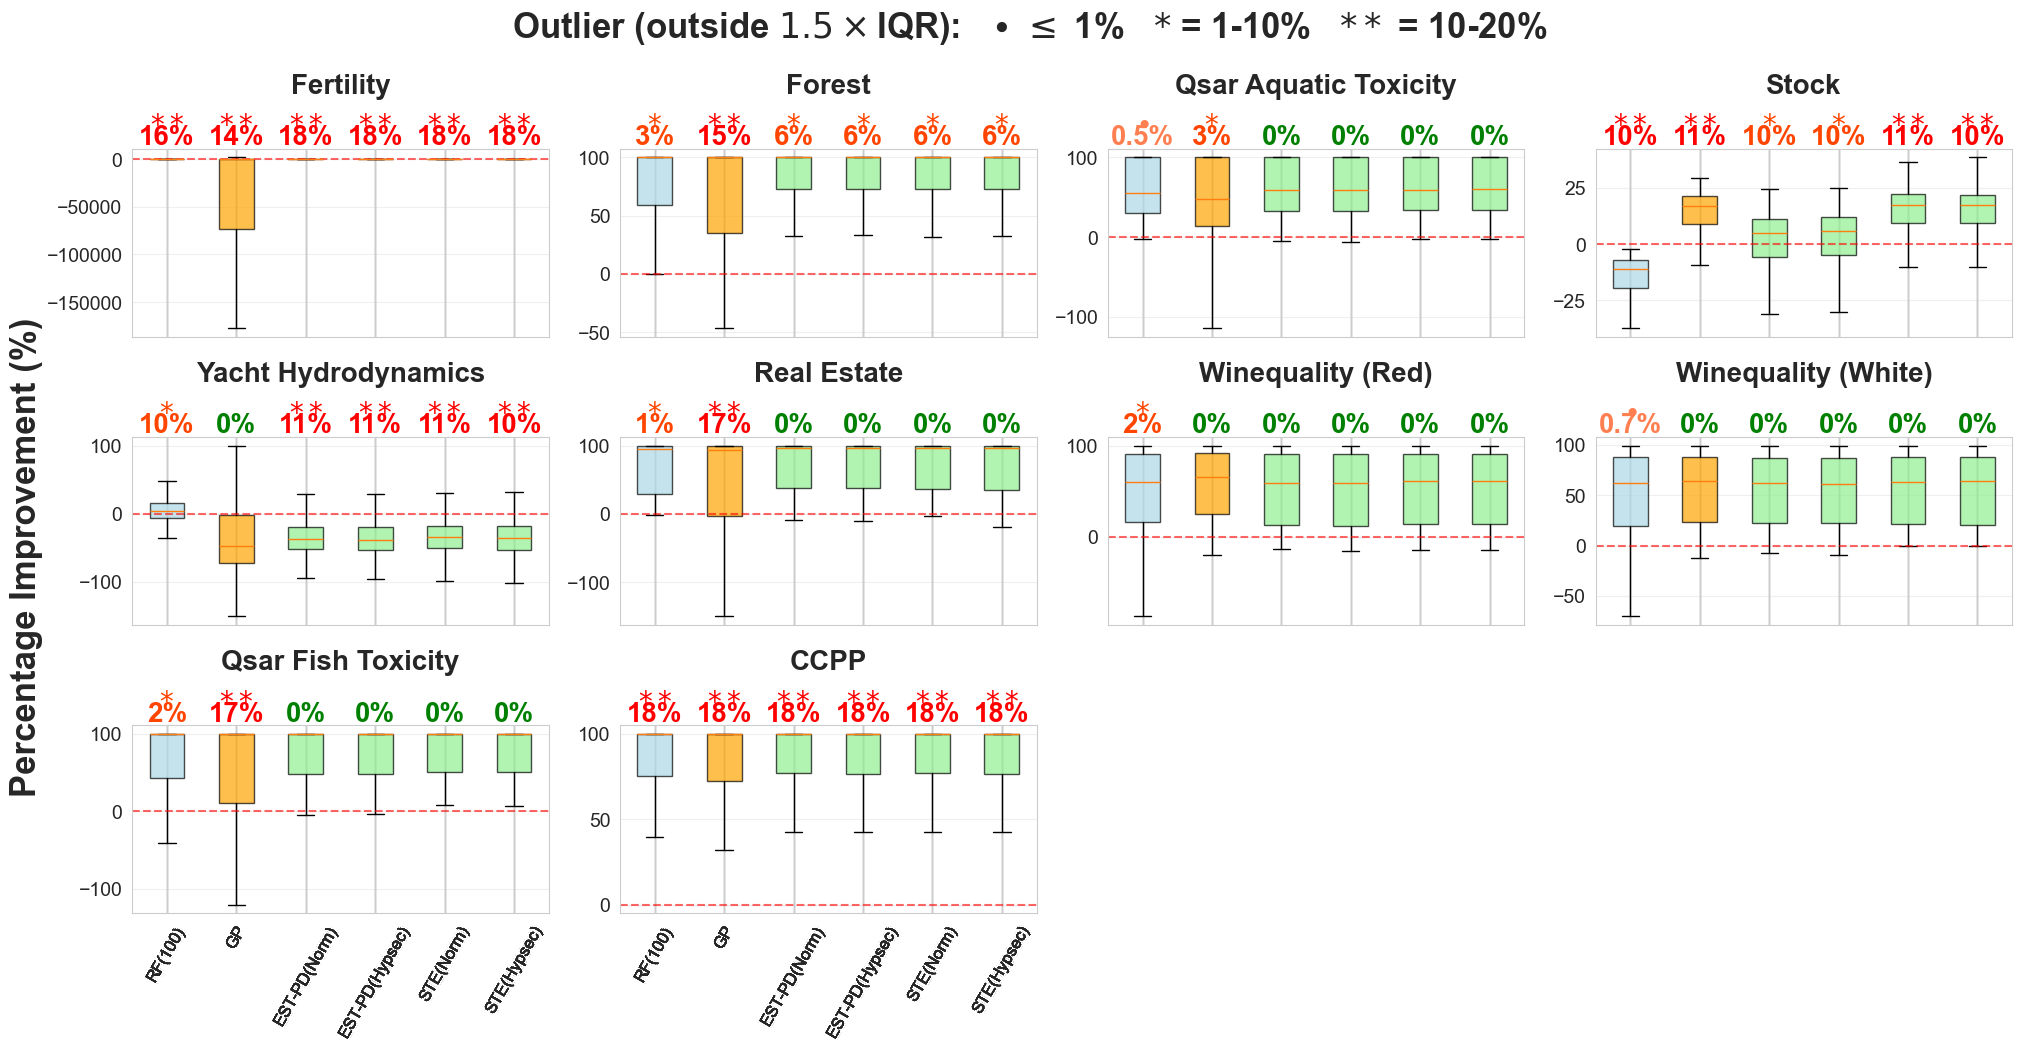

In [59]:
# Model configuration
models = ['RF(100)', 'GP', 'EST-PD(Norm)', 'EST-PD(Hypsec)', 'STE(Norm)', 'STE(Hypsec)']


datasets = df['Data'].unique()

def calculate_outliers_iqr(data, whis=1.5):
    """Calculate outliers using the same method as boxplot"""
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - whis * iqr
    upper_bound = q3 + whis * iqr
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers.sum(), 100 * outliers.sum() / len(data)

# Create grid layout - now 8 datasets, so 2 rows × 4 columns
ncol = 4
rows = len(datasets) // ncol
if len(datasets) % ncol != 0:
    rows += 1

# Create figure with extra space at top for legend
fig, axes = plt.subplots(rows, ncol, figsize=(20, 10), sharex=True, sharey=False)

if rows == 1:
    axes = axes.reshape(1, -1)

# Color configuration
colors = ['lightblue', 'orange', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen']

for i, dataset in enumerate(datasets):
    ax = axes[i // ncol, i % ncol]
    
    # Get data for this dataset
    dataset_df = df[df['Data'] == dataset]
    
    # Prepare data for box plot
    data_for_plot = []
    outlier_percentages = []
    
    for model in models:
        model_data = dataset_df[model].values
        n_outliers, pct_outliers = calculate_outliers_iqr(model_data, whis=1.5)
        outlier_percentages.append(pct_outliers)
        data_for_plot.append(model_data)
    
    # Create box plot WITHOUT showing outliers
    bp = ax.boxplot(data_for_plot, labels=models, showfliers=False,
                    patch_artist=True, whis=1.5)
    
    # Set title
    dataset_name = dataset
    ax.set_title(dataset_name, fontsize=20, fontweight='bold', pad=40)
    
    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=60, labelsize=12)
    ax.tick_params(axis='y', labelsize=14)
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add horizontal line at 0 (reference line)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Color boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # **Asterisk system based on outlier severity**
    y_range = ax.get_ylim()
    y_span = y_range[1] - y_range[0]
    
    for j, pct in enumerate(outlier_percentages):
        # **CHANGED: Show ALL percentages, including 0%**
        x_pos = j + 1
        
        # Determine symbol based on severity
        if pct > 20:
            symbol = r'$***$'
            color_sym = 'darkred'
        elif pct > 10:
            symbol = r'$**$'
            color_sym = 'red'
        elif pct > 1:
            symbol = r'$*$'
            color_sym = 'orangered'
        elif pct > 0.1:
            symbol = r'$\bullet$'  # Bullet point
            color_sym = 'coral'
        else:
            # For 0% or very small values
            symbol = None
            color_sym = 'green'
        
        # Position above the whisker
        y_pos = y_range[1] + y_span * 0.06
        
        # Draw symbol
        ax.text(x_pos, y_pos, symbol,
               ha='center', va='bottom', fontsize=20, 
               fontweight='bold', color=color_sym)
        
        # Add percentage number below the symbol
        if pct >= 1:
            pct_text = f'{pct:.0f}%'
        elif pct >= 0.1:
            pct_text = f'{pct:.1f}%'
        elif pct > 0:
            pct_text = f'{pct:.2f}%'
        else:
            pct_text = '0%'
        
        ax.text(x_pos, y_pos - y_span * 0.07, pct_text,
               ha='center', va='bottom', fontsize=20, 
               fontweight='bold', color=color_sym)

# Hide unused subplots
for i in range(len(datasets), rows * ncol):
    axes[i // ncol, i % ncol].axis('off')

# Add common labels
#fig.text(0.5, -0.01, 'Model', ha='center', fontsize=24, fontweight='bold')
fig.text(-0.01, 0.5, 'Percentage Improvement (%)', 
         va='center', rotation='vertical', fontsize=25, fontweight='bold')

# **Legend at top center without box (using LaTeX symbols)**
legend_text = r'Outlier (outside $1.5\times$IQR):   $\bullet$ $\leq$ 1%   $*$ = 1-10%   $**$ = 10-20%'
fig.text(0.5, 1.01, legend_text, 
         ha='center', va='bottom', fontsize=25, fontweight='bold',
         transform=fig.transFigure)

plt.subplots_adjust(wspace=0.3, hspace=0.4, top=0.94)
plt.tight_layout()
#plt.savefig('logloss_pi_boxplot_with_asterisks.pdf', dpi=300, bbox_inches='tight')
plt.show()

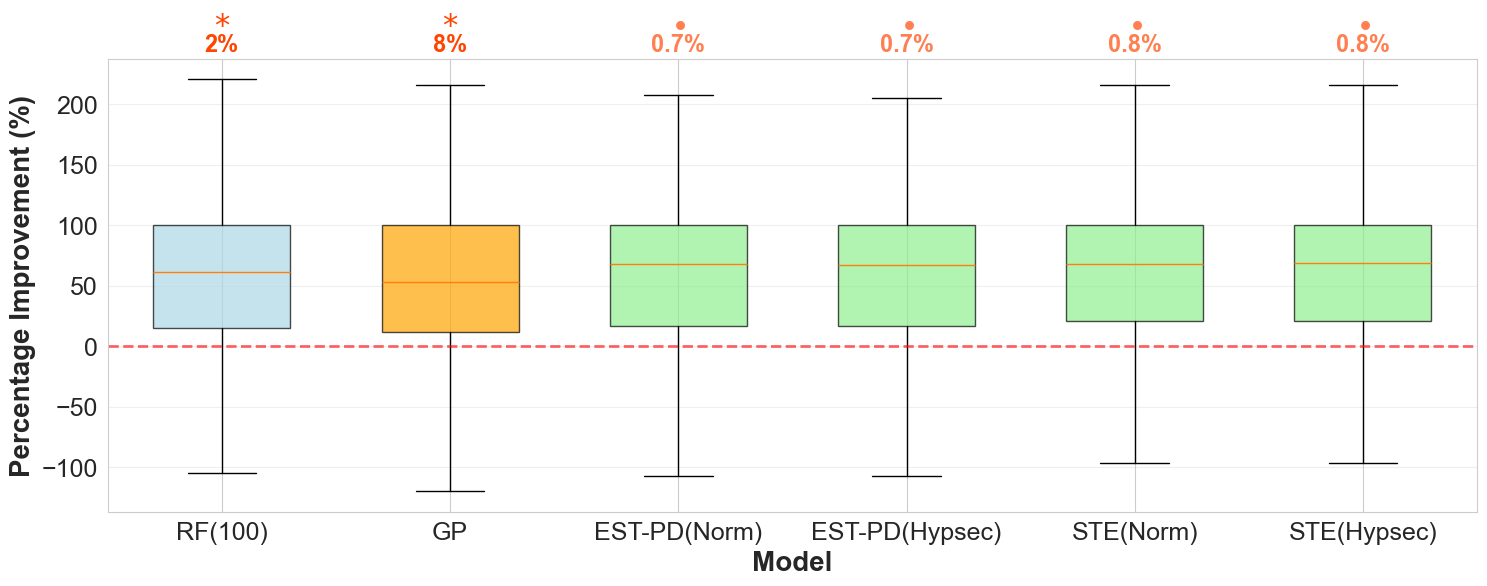

COMBINED STATISTICS ACROSS ALL DATASETS

RF(100):
  Median: 61.63%
  Mean: -104644292115249982569709568.00%
  IQR: [15.52, 100.00]
  Outliers: 1.5%

GP:
  Median: 53.03%
  Mean: -4407.13%
  IQR: [12.01, 100.00]
  Outliers: 7.6%

EST-PD(Norm):
  Median: 67.81%
  Mean: 55.32%
  IQR: [16.96, 100.00]
  Outliers: 0.7%

EST-PD(Hypsec):
  Median: 67.52%
  Mean: 55.16%
  IQR: [16.78, 100.00]
  Outliers: 0.7%

STE(Norm):
  Median: 68.00%
  Mean: 57.02%
  IQR: [21.18, 100.00]
  Outliers: 0.8%

STE(Hypsec):
  Median: 68.53%
  Mean: 56.92%
  IQR: [20.98, 100.00]
  Outliers: 0.8%


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load data
df = pd.read_csv('./logloss_pi.csv')

# Model configuration
models = ['RF(100)', 'GP', 'EST-PD(Norm)', 'EST-PD(Hypsec)', 'STE(Norm)', 'STE(Hypsec)']

def calculate_outliers_iqr(data, whis=1.5):
    """Calculate outliers using the same method as boxplot"""
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - whis * iqr
    upper_bound = q3 + whis * iqr
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers.sum(), 100 * outliers.sum() / len(data)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(15, 6))

# Color configuration
colors = ['lightblue', 'orange', 'lightgreen', 'lightgreen', 'lightgreen', 'lightgreen']

# Group by Data and prepare data for each model
data_for_plot = []
outlier_percentages = []

for model in models:
    # Group by dataset and collect all values for this model
    model_data = df.groupby('Data')[model].apply(lambda x: x.values).values
    # Flatten all dataset values into single array
    model_data_flat = np.concatenate(model_data)
    
    data_for_plot.append(model_data_flat)
    
    # Calculate outliers
    _, pct_outliers = calculate_outliers_iqr(model_data_flat, whis=1.5)
    outlier_percentages.append(pct_outliers)

# Create box plot
bp = ax.boxplot(data_for_plot, labels=models, showfliers=False,
                patch_artist=True, whis=1.5, widths=0.6)


# Tick parameters
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

# Add grid
ax.grid(True, alpha=0.3, axis='y')

# Add horizontal line at 0
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.6)

# Set axis labels
ax.set_xlabel('Model', fontsize=20, fontweight='bold')
ax.set_ylabel('Percentage Improvement (%)', fontsize=20, fontweight='bold')

# Color boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add outlier annotations
y_range = ax.get_ylim()
y_span = y_range[1] - y_range[0]

for j, pct in enumerate(outlier_percentages):
    x_pos = j + 1
    
    # Determine symbol based on severity
    if pct > 20:
        symbol = r'$***$'
        color_sym = 'darkred'
    elif pct > 10:
        symbol = r'$**$'
        color_sym = 'red'
    elif pct > 1:
        symbol = r'$*$'
        color_sym = 'orangered'
    elif pct > 0.1:
        symbol = r'$\bullet$'
        color_sym = 'coral'
    else:
        symbol = '0'
        color_sym = 'green'
    
    # Position above the whisker
    y_pos = y_range[1] + y_span * 0.045
    
    # Draw symbol
    ax.text(x_pos, y_pos, symbol,
           ha='center', va='bottom', fontsize=22, 
           fontweight='bold', color=color_sym)
    
    # Add percentage
    if pct >= 1:
        pct_text = f'{pct:.0f}%'
    elif pct >= 0.1:
        pct_text = f'{pct:.1f}%'
    elif pct > 0:
        pct_text = f'{pct:.2f}%'
    else:
        pct_text = '0%'
    
    ax.text(x_pos, y_pos - y_span * 0.04, pct_text,
           ha='center', va='bottom', fontsize=17, 
           fontweight='bold', color=color_sym)



plt.tight_layout()
#plt.savefig('logloss_pi_boxplot_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("="*80)
print("COMBINED STATISTICS ACROSS ALL DATASETS")
print("="*80)
for i, model in enumerate(models):
    print(f"\n{model}:")
    print(f"  Median: {np.median(data_for_plot[i]):.2f}%")
    print(f"  Mean: {np.mean(data_for_plot[i]):.2f}%")
    print(f"  IQR: [{np.percentile(data_for_plot[i], 25):.2f}, {np.percentile(data_for_plot[i], 75):.2f}]")
    print(f"  Outliers: {outlier_percentages[i]:.1f}%")